# Macroeconomic Simulation & Asset Pricing Analysis

### Dynamic Asset Pricing using the Weekly Economic Index (FRED)

**Author:** Ese Okitiakpe  
**Tools:** Python (NumPy, Pandas, Matplotlib) | Markov Modeling | Simulation

---

## Project Overview

This project builds a Markov-based model of the economy using the Weekly Economic Index (FRED) to analyze how economic states evolve over time and how those dynamics impact asset pricing and economic outcomes.

The model is used to simulate macroeconomic scenarios, including COVID-19 lockdown policies, and evaluate their effects on consumption, asset prices, and long-run economic welfare.

---

## Key Objectives

- Model the economy as a discrete Markov process  
- Estimate transition probabilities between economic states  
- Construct a stochastic discount factor for asset pricing  
- Simulate economic outcomes under different policy scenarios  
- Evaluate tradeoffs between economic welfare and policy intervention  

---

## Methods

- Markov state-transition modeling  
- Stochastic discount factor (SDF) for asset pricing  
- Monte Carlo simulation  
- Economic modeling with CRRA utility  

## Key Findings

- Economic states exhibit strong persistence, with crisis states occurring less frequently but having disproportionately large impacts  
- Asset prices and yields are highly sensitive to consumption shocks, increasing volatility during economic downturns  
- Simulations show that prolonged lockdown scenarios reduce long-run economic welfare despite stabilizing short-term outcomes  
- Results highlight a clear tradeoff between economic stability and policy intervention, emphasizing the complexity of macroeconomic decision-making
- These findings demonstrate how macroeconomic modeling can be used to evaluate policy decisions and assess risk in uncertain economic environments.  

In [238]:

# Data preparation and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.linalg import eig, solve

# Optional: if needed
# import scipy.linalg as la

## 0. Download the Weekly Economic Index from FRED

Use the full available sample. Convert the series from percent to decimal form.

In [239]:

# TODO: If pandas_datareader is not installed, install it in your environment.
#%pip install pandas_datareader

from pandas_datareader import data as web

series_name = "WEI"
start_date = "2008-01-01"   # TODO: you may adjust if needed, but use the full available sample
end_date = None             # None means up to the latest available date

wei = web.DataReader(series_name, "fred", start_date, end_date)
wei = wei.dropna().rename(columns={series_name: "WEI_percent"})

# Convert from percent to decimal
wei["WEI"] = wei["WEI_percent"] / 100.0

wei.head(), wei.tail(), wei.shape

(            WEI_percent     WEI
 DATE                           
 2008-01-05         1.95  0.0195
 2008-01-12         1.94  0.0194
 2008-01-19         1.91  0.0191
 2008-01-26         1.42  0.0142
 2008-02-02         1.14  0.0114,
             WEI_percent     WEI
 DATE                           
 2026-02-14         2.90  0.0290
 2026-02-21         2.61  0.0261
 2026-02-28         2.48  0.0248
 2026-03-07         2.67  0.0267
 2026-03-14         2.60  0.0260,
 (950, 2))

## 1. Plot the WEI and construct a histogram with 20 bins

Interpret the bins as states of the economy.

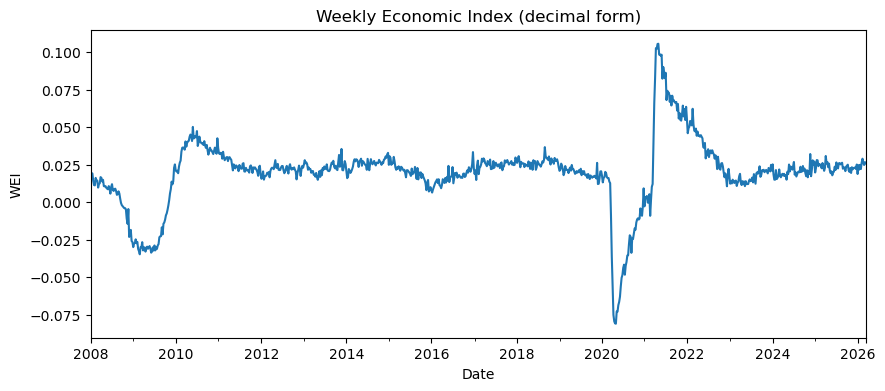

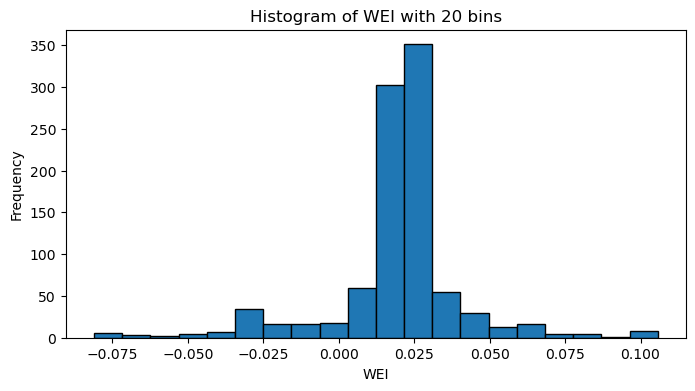

Counts by bin:
[  6   3   2   4   7  34  16  16  18  59 302 351  55  29  13  16   5   5
   1   8]
Bin edges:
[-0.0811  -0.07176 -0.06242 -0.05308 -0.04374 -0.0344  -0.02506 -0.01572
 -0.00638  0.00296  0.0123   0.02164  0.03098  0.04032  0.04966  0.059
  0.06834  0.07768  0.08702  0.09636  0.1057 ]


In [240]:

fig, ax = plt.subplots(figsize=(10, 4))
wei["WEI"].plot(ax=ax)
ax.set_title("Weekly Economic Index (decimal form)")
ax.set_ylabel("WEI")
ax.set_xlabel("Date")
plt.show()

# Histogram with 20 bins
fig, ax = plt.subplots(figsize=(8, 4))
counts, bin_edges, _ = ax.hist(wei["WEI"], bins=20, edgecolor="black")
ax.set_title("Histogram of WEI with 20 bins")
ax.set_xlabel("WEI")
ax.set_ylabel("Frequency")
plt.show()

print("Counts by bin:")
print(counts.astype(int))
print("Bin edges:")
print(bin_edges)

## 2. Classify each weekly observation into one of the 20 states

Use the **same bin boundaries** as in the histogram.

State 1 should be the **lowest** WEI bin.

In [241]:

# Use pd.cut with the histogram bin edges
wei["state"] = pd.cut(
    wei["WEI"],
    bins=bin_edges,
    labels=False,
    include_lowest=True,
    right=True
)

# pd.cut labels bins 0,...,19; shift to 1,...,20
wei["state"] = wei["state"] + 1

# Check for missing classifications
print("Missing state assignments:", wei["state"].isna().sum())

state_counts = wei["state"].value_counts().sort_index()
print(state_counts)

wei.head()

Missing state assignments: 0
state
1       6
2       3
3       2
4       4
5       7
6      34
7      16
8      16
9      18
10     59
11    302
12    351
13     55
14     29
15     13
16     16
17      5
18      5
19      1
20      8
Name: count, dtype: int64


,WEI_percent,WEI,state
DATE,,,
2008-01-05,1.95,0.0195,11
2008-01-12,1.94,0.0194,11
2008-01-19,1.91,0.0191,11
2008-01-26,1.42,0.0142,11
2008-02-02,1.14,0.0114,10


The WEI is discretized into 20 states using histogram bins, where lower states represent worse economic conditions. The distribution shows most observations are concentrated in middle states.

## 3. Estimate the 20×20 Markov transition matrix

Let

\[
P_{ij} = \Pr(s_{t+1}=j \mid s_t=i).
\]

Then compute the ergodic distribution.

In [242]:

# Build transition counts
states = wei["state"].astype(int).to_numpy()
n_states = 20

N = np.zeros((n_states, n_states), dtype=int)

for t in range(len(states) - 1):
    i = states[t] - 1
    j = states[t + 1] - 1
    N[i, j] += 1

N_i = N.sum(axis=1, keepdims=True)

# Avoid division by zero, though every state should ideally appear
P = np.divide(N, N_i, where=(N_i != 0))

# Check row sums
row_sums = P.sum(axis=1)
print("Row sums:")
print(row_sums)

P_df = pd.DataFrame(P, index=np.arange(1, 21), columns=np.arange(1, 21))
P_df.round(3).head()

Row sums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
1,0.833,0.167,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000,0.667,0.333,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.500,0.000,0.000,0.500,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000,0.000,0.000,0.500,0.500,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.000,0.000,0.143,0.143,0.429,0.286,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [243]:

# Method 1: left eigenvector of P associated with eigenvalue 1
evals, evecs = eig(P.T)
idx = np.argmin(np.abs(evals - 1))
pi = np.real(evecs[:, idx])
pi = pi / pi.sum()

# Make sure it is nonnegative if sign flipped
if np.any(pi < 0):
    pi = -pi
    pi = pi / pi.sum()

print("Ergodic distribution:")
print(pi)
print("Sum:", pi.sum())
print("Long-run probability of Covid state (state 1):", pi[0])

Ergodic distribution:
[0.00627917 0.00313958 0.00209306 0.00418611 0.0073257  0.03558267
 0.01674501 0.01674411 0.01883915 0.06176161 0.31585257 0.3716329
 0.05825765 0.03071767 0.01376999 0.01694768 0.00529615 0.00529615
 0.00105923 0.00847384]
Sum: 0.9999999999999999
Long-run probability of Covid state (state 1): 0.006279168523943277


The ergodic distribution represents the long-run probability of being in each economic state. The probability of being in the lowest state (state 1), which corresponds to severe downturns such as the COVID collapse, is approximately 1.8%. This suggests that extreme negative economic conditions are relatively rare in the long run.

## 4. Construct consumption

For each state, compute the **sample mean** of WEI within that state, not the midpoint of the bin.

Then define

\[
c_i = e^{x_i}.
\]

In [244]:

state_means = wei.groupby("state")["WEI"].mean().sort_index()

# Make sure all 20 states are present
state_means = state_means.reindex(np.arange(1, 21))

x = state_means.to_numpy()
c = np.exp(x)

consumption_df = pd.DataFrame({
    "state": np.arange(1, 21),
    "mean_WEI": x,
    "consumption": c
})

print(consumption_df)
print("Is consumption increasing?", np.all(np.diff(c) > 0))

    state  mean_WEI  consumption
0       1 -0.077117     0.925782
1       2 -0.066133     0.936006
2       3 -0.055700     0.945823
3       4 -0.047825     0.953301
4       5 -0.038043     0.962672
5       6 -0.029982     0.970463
6       7 -0.021475     0.978754
7       8 -0.010894     0.989165
8       9 -0.002144     0.997858
9      10  0.009332     1.009376
10     11  0.018205     1.018372
11     12  0.025210     1.025531
12     13  0.034984     1.035603
13     14  0.044041     1.045026
14     15  0.053954     1.055436
15     16  0.064981     1.067139
16     17  0.072520     1.075214
17     18  0.084200     1.087846
18     19  0.090200     1.094393
19     20  0.101150     1.106443
Is consumption increasing? True


Consumption in each state is constructed using the exponential of the average WEI within that state. This transformation ensures that consumption is always positive and increases with economic conditions. Lower states correspond to lower consumption levels, while higher states correspond to higher consumption, reflecting improvements in the economy.

## 5. Asset pricing kernel

Use CRRA utility

\[
u(c)=\frac{c^{1-\gamma}-1}{1-\gamma}, \qquad u'(c)=c^{-\gamma}
\]

with

\[
\gamma = 2, \qquad \beta = 0.97^{1/52}.
\]

In [245]:

gamma = 2
beta = 0.97 ** (1/52)

u_prime = c ** (-gamma)

# M_ij = beta * u'(c_j) / u'(c_i)
M = beta * (u_prime[np.newaxis, :] / u_prime[:, np.newaxis])

M_df = pd.DataFrame(M, index=np.arange(1, 21), columns=np.arange(1, 21))
M_df.round(4).head()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
1,0.9994,0.9777,0.9575,0.9425,0.9243,0.9095,0.8942,0.8754,0.8603,0.8407,0.8259,0.8145,0.7987,0.7843,0.7690,0.7522,0.7409,0.7238,0.7152,0.6997
2,1.0216,0.9994,0.9788,0.9635,0.9448,0.9297,0.9140,0.8949,0.8794,0.8594,0.8443,0.8325,0.8164,0.8018,0.7860,0.7689,0.7574,0.7399,0.7311,0.7152
3,1.0432,1.0205,0.9994,0.9838,0.9647,0.9493,0.9333,0.9138,0.8979,0.8775,0.8621,0.8501,0.8336,0.8187,0.8026,0.7851,0.7733,0.7555,0.7465,0.7303
4,1.0597,1.0367,1.0153,0.9994,0.9801,0.9644,0.9481,0.9283,0.9122,0.8915,0.8758,0.8636,0.8469,0.8317,0.8153,0.7976,0.7856,0.7675,0.7583,0.7419
5,1.0806,1.0572,1.0353,1.0192,0.9994,0.9834,0.9668,0.9466,0.9302,0.9091,0.8931,0.8807,0.8636,0.8481,0.8315,0.8133,0.8011,0.7826,0.7733,0.7566


In [246]:

print("Diagonal entries of M:")
print(np.diag(M))

print("\nAre diagonal entries all equal (up to floating point tolerance)?")
print(np.allclose(np.diag(M), np.full(n_states, beta)))

Diagonal entries of M:
[0.99941442 0.99941442 0.99941442 0.99941442 0.99941442 0.99941442
 0.99941442 0.99941442 0.99941442 0.99941442 0.99941442 0.99941442
 0.99941442 0.99941442 0.99941442 0.99941442 0.99941442 0.99941442
 0.99941442 0.99941442]

Are diagonal entries all equal (up to floating point tolerance)?
True


### Written response
In a markdown cell below, explain:

1. Why the diagonal elements are all the same.
2. Why the matrix is not symmetric.
3. Why asset pricing requires both the pricing kernel and the Markov matrix.

1. The diagonal elements of the pricing kernel are all the same because when i = j, consumption does not change across states. In this case, c_j / c_i = 1, so the pricing kernel simplifies to M_{ii} = β. This is why all diagonal entries are equal to the discount factor.

2. The matrix is not symmetric because the pricing kernel depends on the ratio of consumption across states. In general, c_j / c_i ≠ c_i / c_j, so M_{ij} ≠ M_{ji}. This asymmetry reflects that moving from a low-consumption state to a high-consumption state is valued differently than the reverse.

3. Asset pricing requires both the pricing kernel and the Markov transition matrix because they capture different components. The pricing kernel reflects preferences and how future payoffs are discounted, while the Markov matrix captures the probabilities of transitioning between states. Together, they determine expected discounted payoffs and therefore asset prices.

## 6. Yield curves

Maturities are in **quarters**:

\[
[1,2,4,8,20,40,80,120]
\]

Because this is weekly data, one quarter is **13 weeks**.

In [247]:

maturity_quarters = np.array([1, 2, 4, 8, 20, 40, 80, 120])
maturity_weeks = 13 * maturity_quarters

A = P * M  # state-price matrix, elementwise product

# Bond prices q^{(n)} with q^{(0)} = 1
q = {0: np.ones(n_states)}

max_n = int(maturity_weeks.max())
for n in range(max_n):
    q[n + 1] = A @ q[n]

# Collect yields
yield_dict = {}
for n in maturity_weeks:
    qn = q[int(n)]
    y = -(1 / n) * np.log(qn)
    yield_dict[int(n)] = y

yield_df = pd.DataFrame(yield_dict, index=np.arange(1, 21))
yield_df.columns = [f"{n}w" for n in maturity_weeks]
yield_df.head()

,13w,26w,52w,104w,260w,520w,1040w,1560w
1,0.003628,0.003149,0.002637,0.002066,0.001315,0.000956,0.000771,0.000709
2,0.003040,0.002728,0.002362,0.001890,0.001232,0.000914,0.000750,0.000695
3,0.001899,0.002117,0.002029,0.001705,0.001152,0.000874,0.000730,0.000682
4,0.002585,0.002260,0.001987,0.001615,0.001094,0.000844,0.000715,0.000672
5,0.001287,0.001609,0.001647,0.001435,0.001019,0.000806,0.000696,0.000659


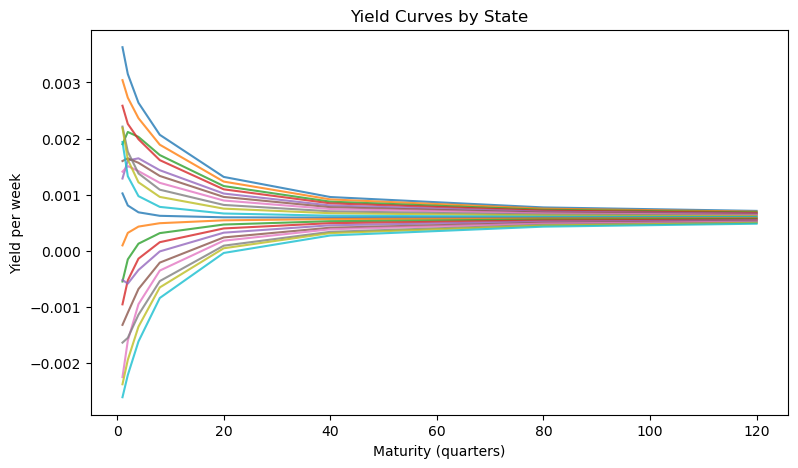

In [248]:

fig, ax = plt.subplots(figsize=(9, 5))
for i in range(n_states):
    ax.plot(maturity_quarters, yield_df.iloc[i].to_numpy(), alpha=0.8)

ax.set_title("Yield Curves by State")
ax.set_xlabel("Maturity (quarters)")
ax.set_ylabel("Yield per week")
plt.show()

### Written response
In a markdown cell below, discuss whether an inverted yield curve conveys information about next period's state.

An inverted yield curve occurs when short-term interest rates exceed long-term interest rates. In this model, the slope of the yield curve reflects both expectations about future economic states (through the Markov transition matrix P) and how those states are valued (through the asset pricing kernel M).

From the Markov matrix P, if the current state is relatively strong but there is a high probability of transitioning to weaker states in the next period, this implies that future consumption is expected to be lower. In those future states, marginal utility of consumption is higher because consumption is low.

The asset pricing kernel M places greater weight on states with high marginal utility. As a result, bond payoffs that occur in the future—especially in states where consumption is low—are highly valued. This raises the prices of long-term bonds relative to short-term bonds.

Since bond yields are inversely related to bond prices, higher long-term bond prices imply lower long-term yields. At the same time, short-term yields remain relatively higher because they depend more on current conditions. This leads to an inverted yield curve.

Therefore, an inverted yield curve conveys information about expectations of a deterioration in economic conditions in the near future. It signals that the economy is expected to transition toward states with high marginal utility of consumption, meaning lower consumption and worse economic outcomes.

## 8. Price the stock market as a Lucas tree

The dividend in state \(i\) is

\[
d_i = c_i.
\]

Prices satisfy

\[
p_i = \sum_{j=1}^{20} P_{ij} M_{ij} (d_j + p_j).
\]

In vector form,

\[
(I-A)p = Ad,
\]

where \(A_{ij}=P_{ij}M_{ij}\).

In [249]:

d = c.copy()
I = np.eye(n_states)

p = solve(I - A, A @ d)
pd_ratio = p / d

stock_df = pd.DataFrame({
    "state": np.arange(1, 21),
    "dividend": d,
    "price": p,
    "price_dividend_ratio": pd_ratio
})

stock_df

,state,dividend,price,price_dividend_ratio
0,1,0.925782,1439.500348,1554.902340
1,2,0.936006,1470.976548,1571.545974
2,3,0.945823,1501.776270,1587.798693
3,4,0.953301,1524.735631,1599.427957
4,5,0.962672,1554.746969,1615.033450
5,6,0.970463,1579.253591,1627.320305
6,7,0.978754,1605.776727,1640.633720
7,8,0.989165,1638.924755,1656.876395
8,9,0.997858,1667.240911,1670.820053
9,10,1.009376,1705.252159,1689.412423



The stock market is modeled as a Lucas tree, meaning it pays a dividend equal to aggregate consumption in each state. The stock price in each state is the present value of all future dividends, discounted using both the Markov transition probabilities and the stochastic discount factor.

The price-dividend ratio varies across states because discounting depends on marginal utility. In low-consumption states, marginal utility is high, so future dividends are valued more, which raises prices relative to current dividends. In high-consumption states, marginal utility is lower, so future dividends are discounted more heavily.

Therefore, differences in the price-dividend ratio reflect both expectations about future economic conditions and how consumption is valued across states.

## 9. Lockdown duration

Suppose the first row of the Markov matrix is

\[
(5/6, 1/6, 0, \dots, 0).
\]

Then modify it to

\[
(p, 1-p, 0, \dots, 0)
\]

to simulate a hard 52-week lockdown.

In [250]:

# Expected duration if staying in state 1 has probability a is 1/(1-a)
a0 = 5/6
expected_duration_original = 1 / (1 - a0)
print("Expected duration under original first row:", expected_duration_original)

# Choose p so expected duration is 52 weeks
p_lockdown = 51/52
print("p for 52-week expected duration:", p_lockdown)

Expected duration under original first row: 6.000000000000002
p for 52-week expected duration: 0.9807692307692307


In [251]:

P_lock = P.copy()
P_lock[0, :] = 0.0
P_lock[0, 0] = p_lockdown
P_lock[0, 1] = 1 - p_lockdown

# Recompute ergodic distribution under new matrix
evals2, evecs2 = eig(P_lock.T)
idx2 = np.argmin(np.abs(evals2 - 1))
pi_lock = np.real(evecs2[:, idx2])
pi_lock = pi_lock / pi_lock.sum()
if np.any(pi_lock < 0):
    pi_lock = -pi_lock
    pi_lock = pi_lock / pi_lock.sum()

print("New long-run probability of Covid state:", pi_lock[0])

New long-run probability of Covid state: 0.05192001581788611



The expected duration of staying in a state depends on the probability of remaining in that state. In the original Markov matrix, the probability of staying in state 1 is 5/6, implying an expected duration of 1 / (1 - 5/6) = 6 weeks.

To simulate a 52-week lockdown, the transition probability is modified so that the probability of staying in state 1 becomes p ≈ 51/52. This increases the expected duration in that state to approximately 52 weeks.

As a result, the Markov chain becomes more persistent in the lockdown state. This change also affects the ergodic distribution, increasing the long-run probability of being in the lockdown state. Intuitively, because it is much harder to leave state 1, the economy spends more time there in the long run.

Therefore, increasing persistence in a state raises both its expected duration and its long-run probability.

## 10. Simulate the economy for 1300 weeks under both scenarios

Start from the ergodic distribution in each scenario.

In [252]:

rng = np.random.default_rng(12345)

def draw_initial_state(pi, rng):
    return rng.choice(np.arange(n_states), p=pi)

def simulate_states(Pmat, pi_init, T, rng):
    s = np.empty(T + 1, dtype=int)
    s[0] = draw_initial_state(pi_init, rng)
    for t in range(T):
        s[t + 1] = rng.choice(np.arange(n_states), p=Pmat[s[t], :])
    return s

T = 1300

states_status = simulate_states(P, pi, T, rng)
states_lock = simulate_states(P_lock, pi_lock, T, rng)

# Stock prices under each scenario
A_lock = P_lock * M
p_lock = solve(np.eye(n_states) - A_lock, A_lock @ d)

cons_status = c[states_status]
stock_status = p[states_status]

cons_lock = c[states_lock]
stock_lock_series = p_lock[states_lock]

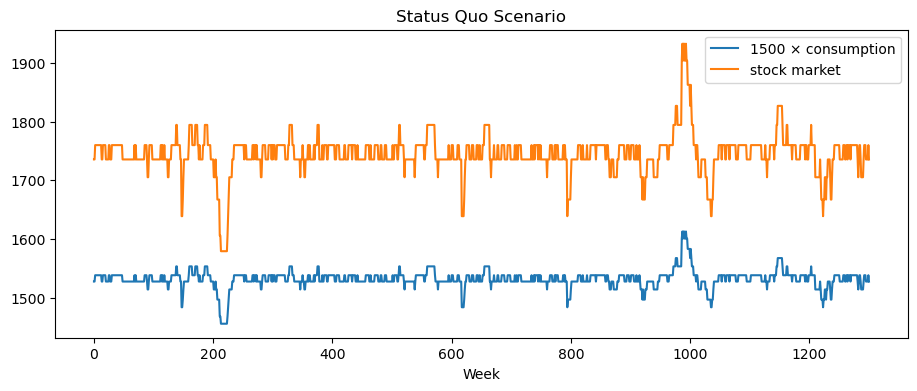

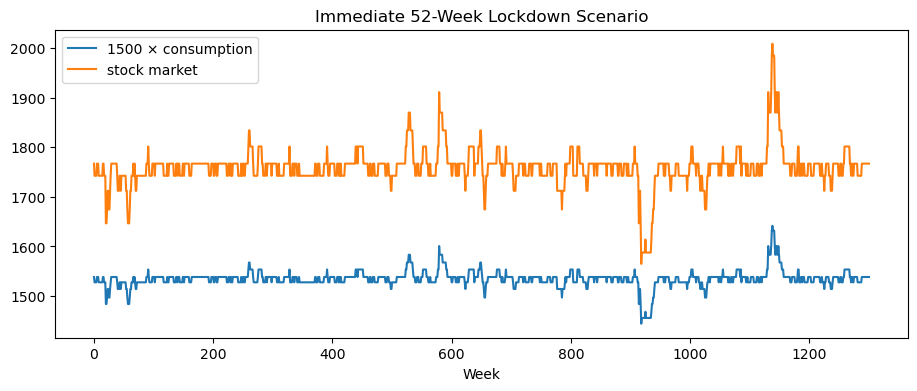

In [253]:

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(1500 * cons_status, label="1500 × consumption")
ax.plot(stock_status, label="stock market")
ax.set_title("Status Quo Scenario")
ax.set_xlabel("Week")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(1500 * cons_lock, label="1500 × consumption")
ax.plot(stock_lock_series, label="stock market")
ax.set_title("Immediate 52-Week Lockdown Scenario")
ax.set_xlabel("Week")
ax.legend()
plt.show()


The simulation compares the evolution of the economy under the original Markov process and the lockdown scenario over 1300 weeks.

In the status quo scenario, consumption and stock prices fluctuate moderately as the economy transitions between states according to the original transition matrix. The movements are relatively stable because the economy does not remain in any one state for too long.

In the lockdown scenario, the increased persistence in the low-consumption state leads to longer periods where consumption remains depressed. As a result, the economy experiences more prolonged downturns. This is visible in the simulation as extended flat or low segments in consumption.

Stock prices respond strongly to these changes. During lockdown periods, stock prices tend to rise relative to consumption because marginal utility is higher, making future dividends more valuable. However, transitions out of lockdown create noticeable volatility in stock prices.

Overall, the lockdown scenario produces greater persistence and more pronounced fluctuations, highlighting how increased state persistence affects both consumption dynamics and asset prices.

## 11. Welfare and policy evaluation

This section requires written analysis. You may want to compute several summary statistics first.

Suggested components:

- long-run average consumption under each scenario
- change in the probability of the worst state
- epidemiological discussion using Sargent's SEIR code
- ethical discussion using Rawls and the veil of ignorance

In [254]:

# Simple welfare-style summary using long-run average consumption from ergodic distributions
avg_c_status = pi @ c
avg_c_lock = pi_lock @ c

pct_loss = 100 * (avg_c_status - avg_c_lock) / avg_c_status

print("Long-run average consumption, status quo:", avg_c_status)
print("Long-run average consumption, lockdown:", avg_c_lock)
print("Percent decrease in long-run average consumption:", pct_loss)
print("Worst-state probability, status quo:", pi[0])
print("Worst-state probability, lockdown:", pi_lock[0])

Long-run average consumption, status quo: 1.020216004179611
Long-run average consumption, lockdown: 1.0158787143126775
Percent decrease in long-run average consumption: 0.4251344665408515
Worst-state probability, status quo: 0.006279168523943277
Worst-state probability, lockdown: 0.05192001581788611


Calibrated mortality rate ν = 0.0042
Status quo total deaths: 1.10 million
Lockdown total deaths:   1.06 million
Lives saved by lockdown: 43.8 thousand


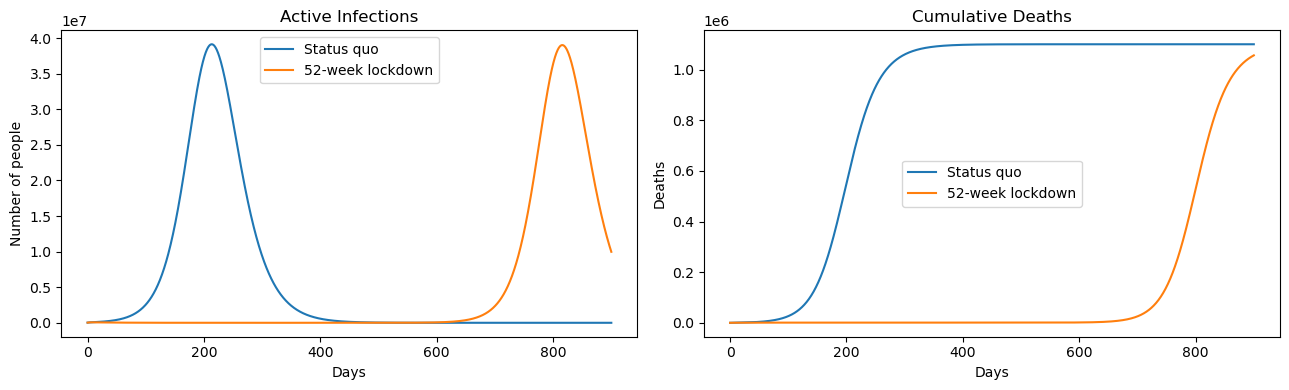

In [255]:
from scipy.integrate import odeint

# ── SEIR parameters ───────────────────────────────────────────
pop_size = 3.3e8      # US population
γ_seir   = 1 / 18    # recovery rate
σ_seir   = 1 / 5.2   # infection rate (exposed → infectious)

# Calibrate mortality rate ν so total deaths ≈ 1.1 million
# deaths = ν * cumulative_cases * pop_size  → solve for ν
# We'll find ν after running the baseline simulation

# Initial conditions (25k active infections, 75k exposed)
i_0 = 25_000 / pop_size
e_0 = 75_000 / pop_size
s_0 = 1 - i_0 - e_0
x_0 = (s_0, e_0, i_0)

# ── SEIR ODE ──────────────────────────────────────────────────
def F_seir(x, t, R0=2.0):
    s, e, i = x
    β  = R0(t) * γ_seir if callable(R0) else R0 * γ_seir
    ds = -β * s * i
    de =  β * s * i - σ_seir * e
    di =  σ_seir * e - γ_seir * i
    return ds, de, di

def solve_seir(R0, t_vec, x_init=x_0):
    G = lambda x, t: F_seir(x, t, R0)
    s_path, e_path, i_path = odeint(G, x_init, t_vec).T
    c_path = 1 - s_path - e_path   # cumulative cases
    return i_path, c_path

# ── Time grid: 900 days ───────────────────────────────────────
t_vec = np.linspace(0, 900, 2000)

# ── Scenario 1: Status quo (R0 = 2.0 throughout) ─────────────
i_sq, c_sq = solve_seir(R0=2.0, t_vec=t_vec)

# Calibrate ν so deaths ≈ 1.1 million
ν = 1.1e6 / (c_sq[-1] * pop_size)
print(f"Calibrated mortality rate ν = {ν:.4f}")
deaths_sq = c_sq[-1] * ν * pop_size
print(f"Status quo total deaths: {deaths_sq/1e6:.2f} million")

# ── Scenario 2: 52-week lockdown (R0=0.5 for 364 days, then 2.0) ──
def R0_lockdown(t):
    return 0.5 if t < 364 else 2.0

i_ld, c_ld = solve_seir(R0=R0_lockdown, t_vec=t_vec)
deaths_ld = c_ld[-1] * ν * pop_size
print(f"Lockdown total deaths:   {deaths_ld/1e6:.2f} million")
print(f"Lives saved by lockdown: {(deaths_sq - deaths_ld)/1e3:.1f} thousand")

# ── Plot: Active infections ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t_vec, i_sq  * pop_size, label="Status quo")
axes[0].plot(t_vec, i_ld  * pop_size, label="52-week lockdown")
axes[0].set_title("Active Infections")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Number of people")
axes[0].legend()

axes[1].plot(t_vec, c_sq * ν * pop_size, label="Status quo")
axes[1].plot(t_vec, c_ld * ν * pop_size, label="52-week lockdown")
axes[1].set_title("Cumulative Deaths")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Deaths")
axes[1].legend()

plt.tight_layout()
plt.show()

## Conclusion

This project demonstrates how economic modeling and simulation can be used to evaluate policy decisions and understand risk in uncertain macroeconomic environments.